# 04 — 条件路由示例

**来源:** [菜鸟教程 — LangGraph 入门教程](https://www.runoob.com/ai-agent/langgraph-quick-start.html)

条件边是 LangGraph 的核心功能，根据当前 State 动态决定下一步流向。

## 1. 普通边

固定路径，节点执行后始终流向指定节点。

In [ ]:
# 固定路径：node_a 完成后始终执行 node_b
# builder.add_edge("node_a", "node_b")
# builder.add_edge("node_a", END)
print("普通边示例")


## 2. 条件边

条件边根据 State 动态路由到不同节点。

In [ ]:
from langgraph.graph.message import add_messages
from typing import TypedDict, Annotated


class AgentState(TypedDict):
    """状态定义"""
    messages: Annotated[list, add_messages]


def route_after_llm(state: AgentState) -> str:
    """路由函数：返回值必须是已注册节点名称或 END"""
    last_message = state["messages"][-1]
    if hasattr(last_message, "tool_calls") and last_message.tool_calls:
        return "tools"
    return "__end__"


# builder.add_conditional_edges(
#     "llm",
#     route_after_llm,
#     {
#         "tools": "tool_executor",
#         "__end__": "__end__"
#     }
# )
print("条件边路由函数定义完成")


## 3. 并行执行（Fan-out / Fan-in）

In [ ]:
# 从一个节点并行分叉到多个节点
# builder.add_edge("start_node", "branch_a")
# builder.add_edge("start_node", "branch_b")
# builder.add_edge("start_node", "branch_c")

# 多个节点汇聚到一个节点
# builder.add_edge("branch_a", "merge_node")
# builder.add_edge("branch_b", "merge_node")
# builder.add_edge("branch_c", "merge_node")
print("Fan-out / Fan-in 模式")


## 4. 完整条件路由示例

构建一个根据用户意图路由到不同 Agent 的工作流。

```mermaid
graph LR
    START --> Router
    Router -- "天气" --> weather_agent
    Router -- "代码" --> code_agent
    Router -- "其他" --> general_agent
    Router -- "再见" --> END
```


用户: 北京今天天气怎么样？
助手: 您好！我暂时无法获取实时的天气数据，不过通常北京这个时候（春季）气温变化比较大，早晚可能有点凉，中午会暖和些。建议您出门前查看一下权威的天气预报，根据实际气温穿件方便穿脱的外套，带上太阳镜或口罩以防风...
--------------------------------------------------

用户: 帮我写一个 Python 快速排序
助手: 下面是一个经典的快速排序实现，包含详细注释：

```python
def quicksort(arr):
    """
    快速排序（递归实现）
    参数:
        arr: 待排...
--------------------------------------------------

用户: 你好，介绍一下你自己
助手: 你好呀！很高兴认识你！😊

我是 **DeepSeek**，一个由深度求索公司创造的 AI 助手。简单来说，我就是一个乐于助人的“数字小伙伴”，可以陪你聊天、回答问题、提供建议，或者帮你处理各种文字相...
--------------------------------------------------

用户: 再见啦！
助手: 再见！期待下次与你交流。...
--------------------------------------------------


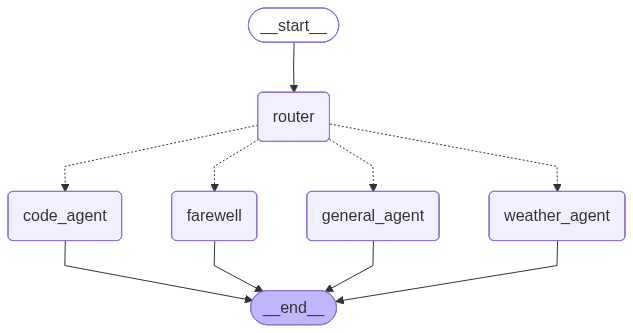

In [1]:
from dotenv import load_dotenv
load_dotenv()

import os
from langgraph.graph import StateGraph, START, END, MessagesState
from langchain_deepseek import ChatDeepSeek
from langchain_core.messages import SystemMessage, HumanMessage
from IPython.display import Image, display

# 初始化 LLM
llm = ChatDeepSeek(
    model='deepseek-v4-pro',
    temperature=0.7
)


# 路由函数
def classify_intent(state: MessagesState) -> str:
    """根据用户意图路由到不同的 Agent"""
    last_message = state["messages"][-1]
    content = last_message.content.lower()

    if "天气" in content or "温度" in content:
        return "weather_agent"
    elif "代码" in content or "编程" in content:
        return "code_agent"
    elif "再见" in content or "退出" in content:
        return "farewell"
    else:
        return "general_agent"


# 定义各个 Agent 节点
def router_node(state: MessagesState) -> dict:
    """路由节点：不做处理，只用于触发路由判断"""
    return {}


def weather_node(state: MessagesState) -> dict:
    """天气 Agent"""
    response = llm.invoke([
        SystemMessage(content="你是一个天气助手，友好地回答天气相关问题。如果没有实时数据，可以给出一般性建议。"),
        *state["messages"]
    ])
    return {"messages": [response]}


def code_node(state: MessagesState) -> dict:
    """代码 Agent"""
    response = llm.invoke([
        SystemMessage(content="你是一个编程助手，擅长解答代码问题并给出清晰的代码示例。"),
        *state["messages"]
    ])
    return {"messages": [response]}


def general_node(state: MessagesState) -> dict:
    """通用 Agent"""
    response = llm.invoke([
        SystemMessage(content="你是一个友善的 AI 助手，可以回答各种问题。"),
        *state["messages"]
    ])
    return {"messages": [response]}


def farewell_node(state: MessagesState) -> dict:
    """告别节点"""
    return {"messages": [{"role": "assistant", "content": "再见！期待下次与你交流。"}]}


# 构建图
builder = StateGraph(MessagesState)
builder.add_node("router", router_node)
builder.add_node("weather_agent", weather_node)
builder.add_node("code_agent", code_node)
builder.add_node("general_agent", general_node)
builder.add_node("farewell", farewell_node)

builder.add_edge(START, "router")
builder.add_conditional_edges(
    "router",
    classify_intent,
    {
        "weather_agent": "weather_agent",
        "code_agent": "code_agent",
        "general_agent": "general_agent",
        "farewell": "farewell",
    }
)

for node in ["weather_agent", "code_agent", "general_agent", "farewell"]:
    builder.add_edge(node, END)

graph = builder.compile()

# 测试不同意图
test_inputs = [
    "北京今天天气怎么样？",
    "帮我写一个 Python 快速排序",
    "你好，介绍一下你自己",
    "再见啦！"
]

for user_input in test_inputs:
    print(f"\n用户: {user_input}")
    result = graph.invoke({"messages": [HumanMessage(content=user_input)]})
    print(f"助手: {result['messages'][-1].content[:100]}...")
    print("-" * 50)

display(Image(graph.get_graph().draw_mermaid_png()))
